In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-price-prediction-dataset/cardekho.csv


**EDA for vehicle price prediction dataset**
**Check the bottom for the preliminary observations**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
path = '/kaggle/input/car-price-prediction-dataset/cardekho.csv'
df = pd.read_csv(path)

df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [5]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [6]:
df = df.drop_duplicates()

df.isna().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    208
engine                208
max_power             205
seats                 208
dtype: int64

In [7]:
df = df.dropna()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


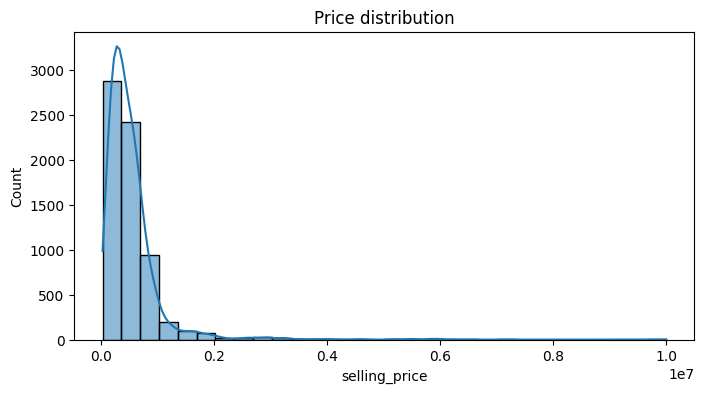

In [8]:
df['selling_price'].describe()

plt.figure(figsize=(8,4))
sns.histplot(df['selling_price'], bins = 30, kde = True)
plt.title("Price distribution")
plt.show()

In [9]:
df['selling_price'].skew()

5.57056222208384

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


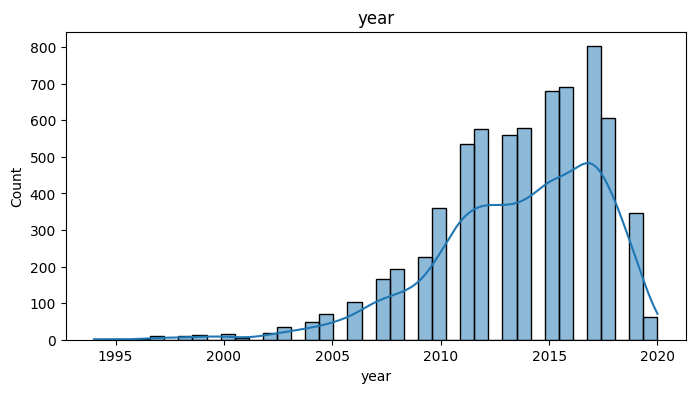

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


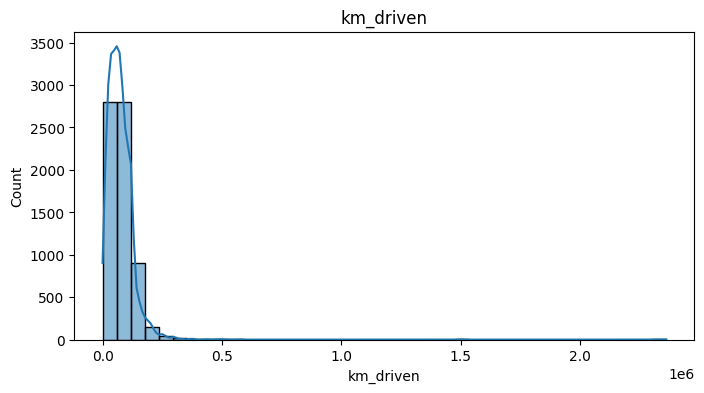

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


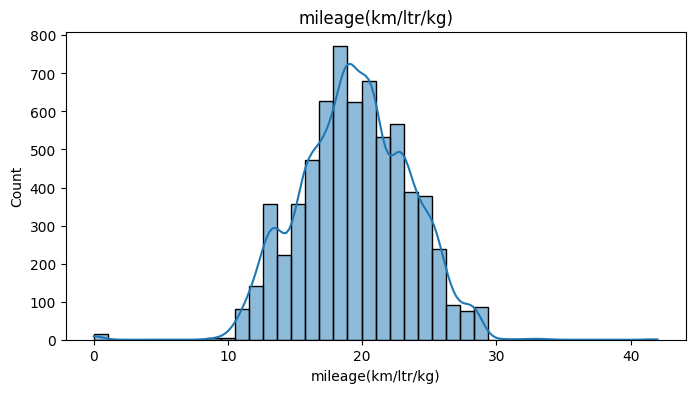

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


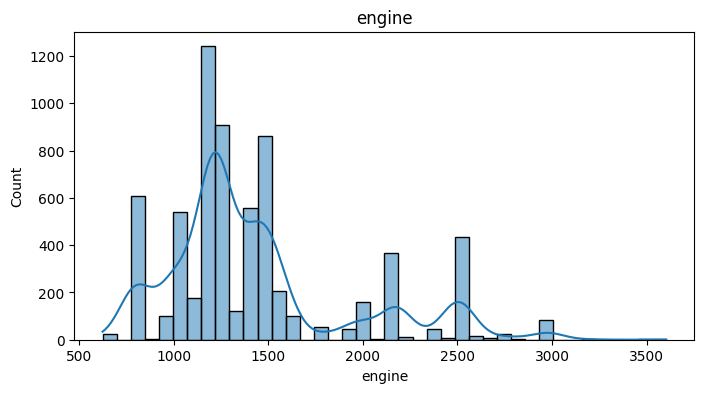

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


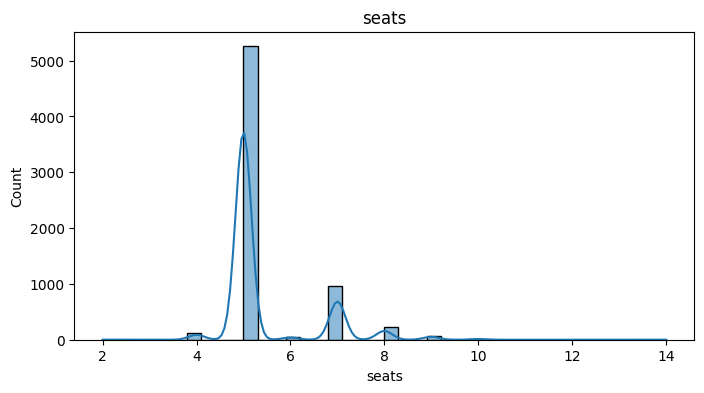

In [10]:
num = df.select_dtypes(include=[np.number]).columns.drop('selling_price')

for col in num:
    plt.figure(figsize = (8,4))
    sns.histplot(df[col], bins = 40, kde = True)
    plt.title(col)
    plt.show()

In [11]:
cat = df.select_dtypes(include=['object']).columns

for col in cat:
    print(col, df[col].nunique())

name 1983
fuel 4
seller_type 3
transmission 2
owner 5
max_power 319


In [12]:
for col in cat:
    print("\n", col)
    print(df[col].value_counts().head(10))



 name
name
Maruti Swift Dzire VDI      118
Maruti Alto 800 LXI          76
Maruti Alto LXi              69
Maruti Swift VDI             60
Maruti Alto K10 VXI          47
Hyundai EON Era Plus         44
Maruti Wagon R VXI BS IV     43
Maruti Alto LX               43
Maruti Ertiga VDI            42
Maruti Ritz VDi              40
Name: count, dtype: int64

 fuel
fuel
Diesel    3658
Petrol    2973
CNG         52
LPG         35
Name: count, dtype: int64

 seller_type
seller_type
Individual          6025
Dealer               666
Trustmark Dealer      27
Name: count, dtype: int64

 transmission
transmission
Manual       6143
Automatic     575
Name: count, dtype: int64

 owner
owner
First Owner             4176
Second Owner            1889
Third Owner              493
Fourth & Above Owner     155
Test Drive Car             5
Name: count, dtype: int64

 max_power
max_power
74       324
88.5     193
46.3     158
67       152
67.1     141
81.8     136
67.04    136
70       134
47.3     131
62.

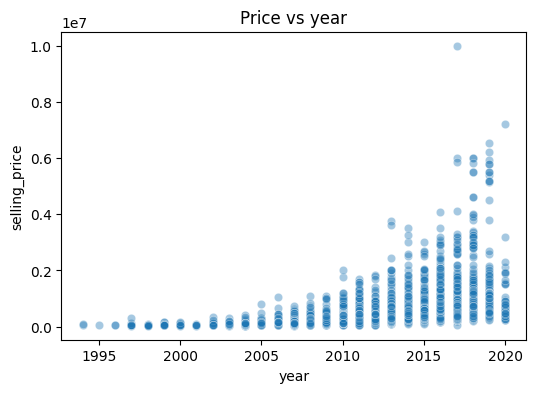

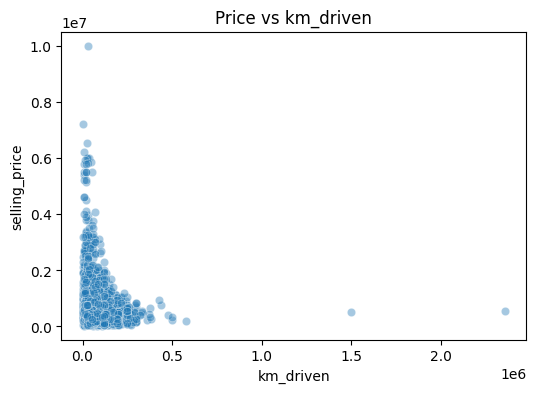

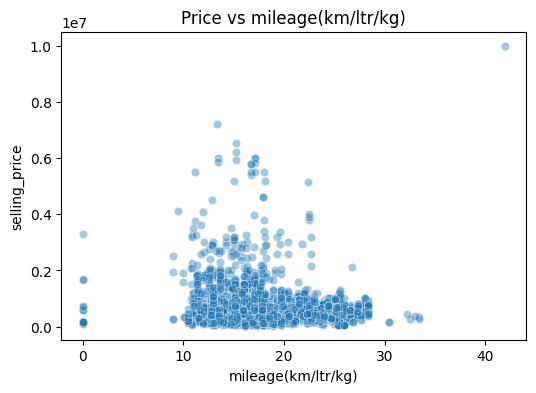

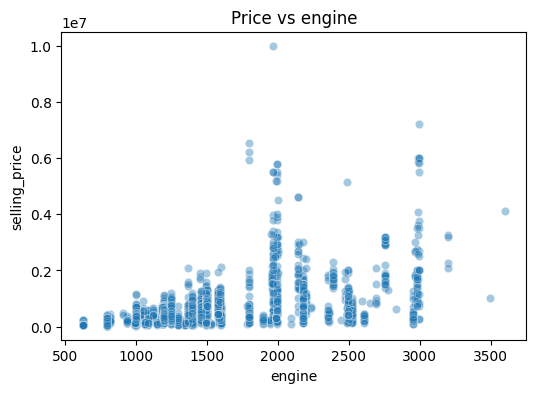

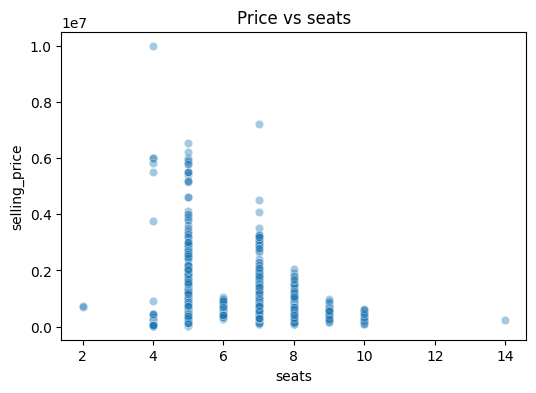

In [13]:
for col in num:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y='selling_price', alpha=0.4)
    plt.title(f"Price vs {col}")
    plt.show()


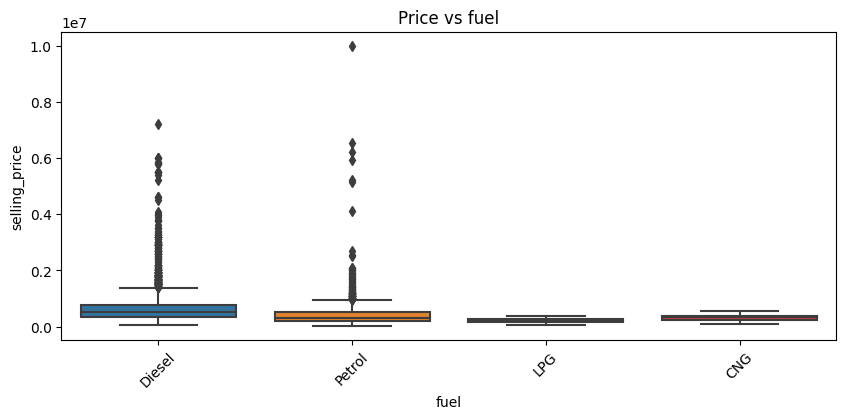

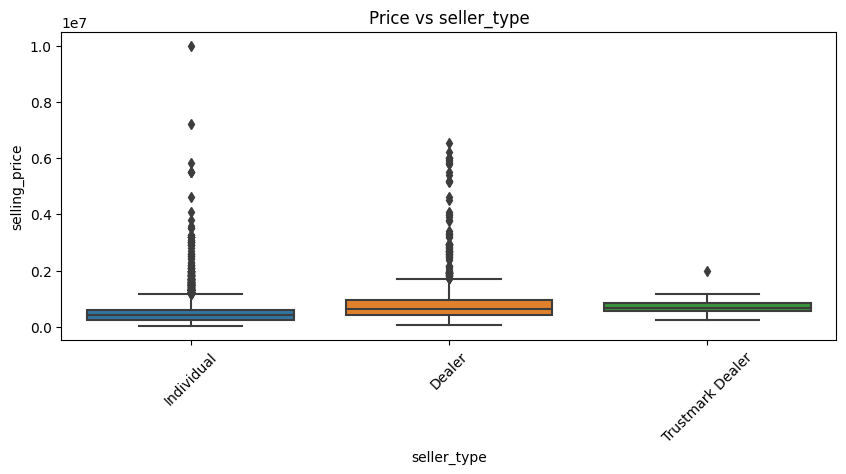

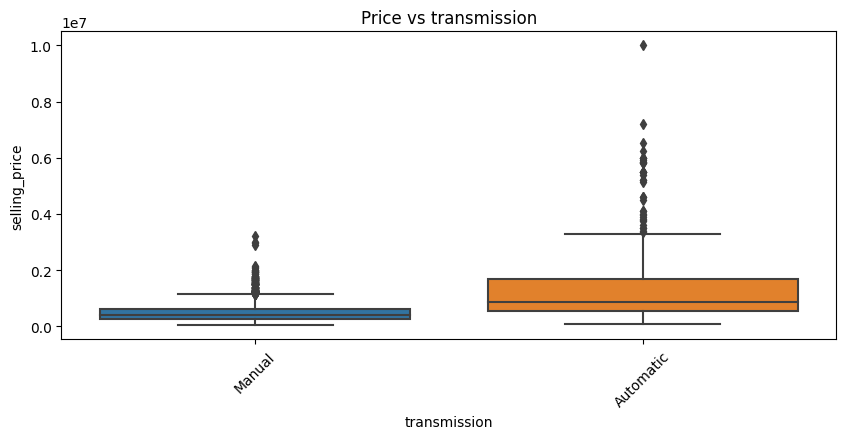

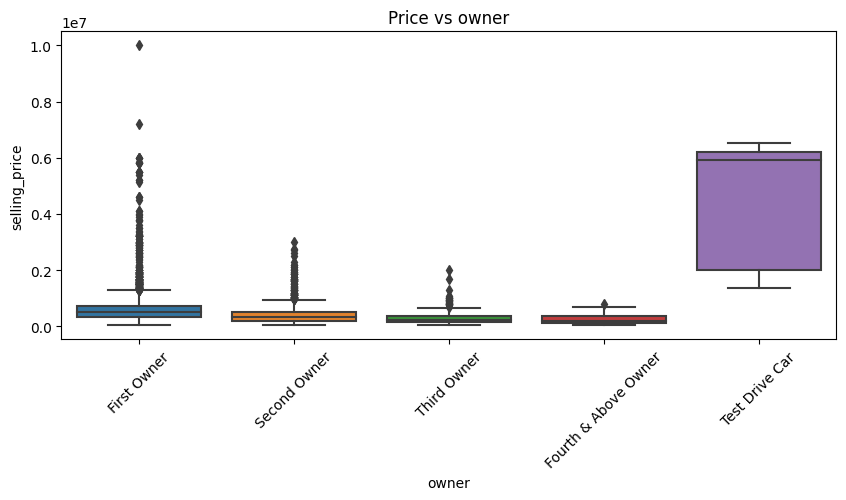

In [15]:
for col in cat:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(10,4))
        sns.boxplot(data=df, x=col, y='selling_price')
        plt.title(f"Price vs {col}")
        plt.xticks(rotation=45)
        plt.show()

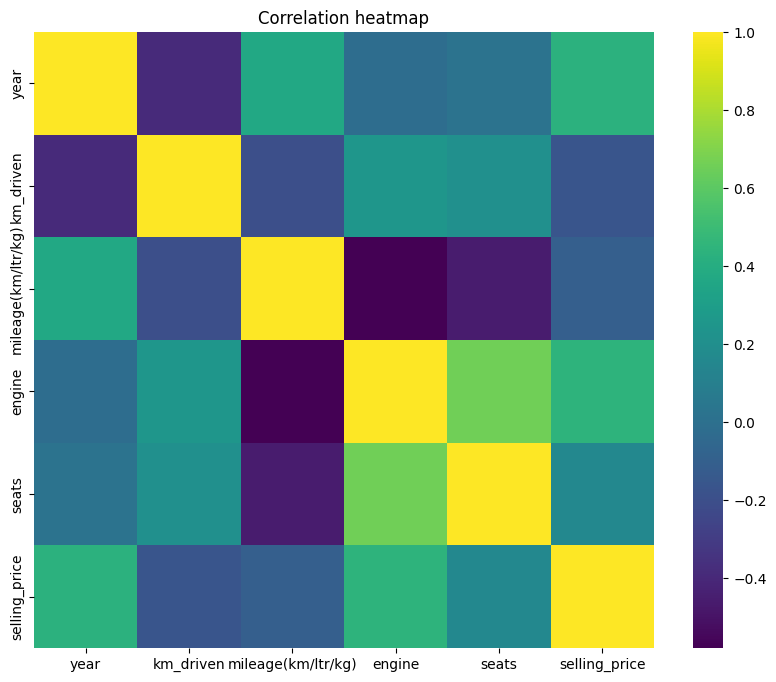

In [18]:
corr = df[num.tolist() + ['selling_price']].corr()

plt.figure(figsize = (10,8))
sns.heatmap(corr, annot=False, cmap='viridis')
plt.title("Correlation heatmap")
plt.show()

In [20]:
corr['selling_price'].sort_values(ascending=False)

selling_price         1.000000
engine                0.442857
year                  0.427367
seats                 0.158111
mileage(km/ltr/kg)   -0.108344
km_driven            -0.161311
Name: selling_price, dtype: float64

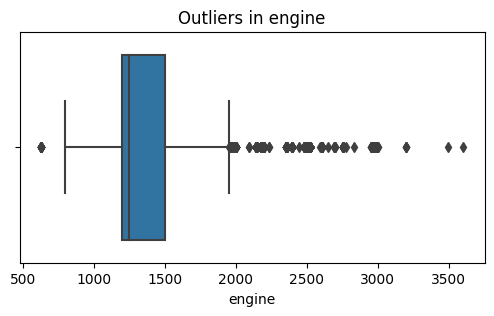

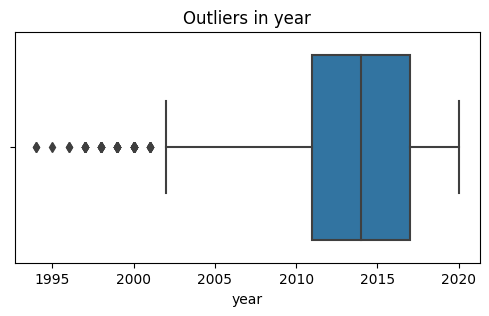

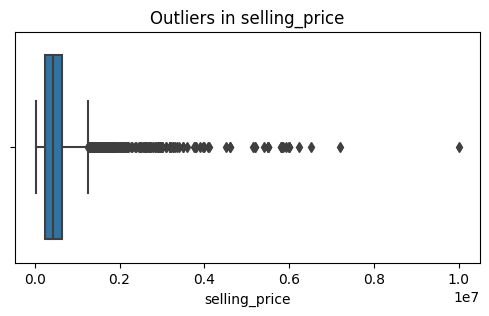

In [24]:
for col in ['engine', 'year', 'selling_price']:
    if col in df.columns:
        plt.figure(figsize = (6,3))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers in {col}")
        plt.show()